# Alert Prioritization Notebook

가상 거래 데이터에 5개 AML 탐지 룰을 적용하고, 각 alert에 위험 점수를 부여해 검토 우선순위를 분류합니다.

- 데이터: `../data/customers.csv`, `../data/transactions.csv` (Faker로 생성된 가상 데이터)
- 룰 정의: `../sql/*.sql`
- 출력: `../outputs/sample_alerts.csv`


In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", "{:,.0f}".format)

DATA_DIR = Path("..") / "data"
SQL_DIR = Path("..") / "sql"
OUT_DIR = Path("..") / "outputs"
OUT_DIR.mkdir(exist_ok=True)


In [2]:
# CSV를 in-memory SQLite DB에 적재
customers = pd.read_csv(DATA_DIR / "customers.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")

conn = sqlite3.connect(":memory:")
customers.to_sql("customers", conn, index=False)
transactions.to_sql("transactions", conn, index=False)

print(f"customers: {len(customers)} rows")
print(f"transactions: {len(transactions)} rows")


customers: 100 rows
transactions: 519 rows


## Step 1. Apply 5 detection rules

각 .sql 파일을 읽어 in-memory DB에 실행하고, 룰별 hit 건수를 확인합니다.


In [3]:
rule_results = {}
for sql_file in sorted(SQL_DIR.glob("*.sql")):
    rule_name = sql_file.stem.split("_", 1)[1]  # '01_daily_cash_aggregation' -> 'daily_cash_aggregation'
    sql_text = sql_file.read_text(encoding="utf-8")
    df = pd.read_sql(sql_text, conn)
    rule_results[rule_name] = df
    print(f"{rule_name}: {len(df)} hits")


daily_cash_aggregation: 1 hits
structured_transactions: 3 hits
new_account_large_txn: 19 hits
shared_device_multi_account: 28 hits
profile_mismatch: 1 hits


In [4]:
# 참고: 각 룰의 상위 3건 샘플
for rule_name, df in rule_results.items():
    print(f"\n--- {rule_name} ---")
    print(df.head(3).to_string(index=False))



--- daily_cash_aggregation ---
customer_id   txn_date  daily_cash_total  txn_count              rule_name
      C0001 2026-03-10          15000000          3 daily_cash_aggregation

--- structured_transactions ---
customer_id window_start_date  txn_count  total_amount               rule_name
      C0002        2026-03-05          4      37700000 structured_transactions
      C0002        2026-03-07          3      28600000 structured_transactions
      C0045        2026-04-01          3      28300000 structured_transactions

--- new_account_large_txn ---
customer_id onboarding_date   txn_date  days_since_onboarding   amount cash_yn    channel             rule_name
      C0030      2026-01-14 2026-02-05                     22 20000000       N        WEB new_account_large_txn
      C0030      2026-01-14 2026-02-12                     29 18000000       N        WEB new_account_large_txn
      C0023      2026-03-15 2026-03-19                      4 15000000       N MOBILE_APP new_account_

## Step 2. Assign risk scores

각 룰에 heuristic 가중치를 부여합니다. 실무에서는 과거 STR 보고 결과 대비 룰별 정확도(PPV) 기반으로 조정되어야 합니다.


In [5]:
risk_weights = {
    "daily_cash_aggregation":      20,
    "structured_transactions":     25,
    "new_account_large_txn":       20,
    "shared_device_multi_account": 15,
    "profile_mismatch":            20,
}
risk_weights


{'daily_cash_aggregation': 20,
 'structured_transactions': 25,
 'new_account_large_txn': 20,
 'shared_device_multi_account': 15,
 'profile_mismatch': 20}

In [6]:
# 고객별 triggered rules 및 누적 점수 산출
from collections import defaultdict

customer_triggers = defaultdict(set)

# daily_cash_aggregation -> per customer
for _, row in rule_results["daily_cash_aggregation"].iterrows():
    customer_triggers[row["customer_id"]].add("daily_cash_aggregation")

# structured_transactions -> per customer
for _, row in rule_results["structured_transactions"].iterrows():
    customer_triggers[row["customer_id"]].add("structured_transactions")

# new_account_large_txn -> per customer
for _, row in rule_results["new_account_large_txn"].iterrows():
    customer_triggers[row["customer_id"]].add("new_account_large_txn")

# shared_device_multi_account -> 해당 device의 모든 고객에 표시
for _, row in rule_results["shared_device_multi_account"].iterrows():
    for cid in row["customer_list"].split(","):
        customer_triggers[cid.strip()].add("shared_device_multi_account")

# profile_mismatch -> per customer
for _, row in rule_results["profile_mismatch"].iterrows():
    customer_triggers[row["customer_id"]].add("profile_mismatch")

scored = []
for cid, rules in customer_triggers.items():
    score = sum(risk_weights[r] for r in rules)
    scored.append({
        "customer_id": cid,
        "triggered_rules": ", ".join(sorted(rules)),
        "rule_count": len(rules),
        "risk_score": score,
    })

alerts = pd.DataFrame(scored).sort_values("risk_score", ascending=False).reset_index(drop=True)
print(f"Total customers with at least one alert: {len(alerts)}")
alerts.head(10)


Total customers with at least one alert: 80


,customer_id,triggered_rules,rule_count,risk_score
0,C0045,"new_account_large_txn, shared_device_multi_acc...",3,60
1,C0030,"new_account_large_txn, profile_mismatch, share...",3,55
2,C0002,"shared_device_multi_account, structured_transa...",2,40
3,C0001,"daily_cash_aggregation, shared_device_multi_ac...",2,35
4,C0023,"new_account_large_txn, shared_device_multi_acc...",2,35
5,C0060,"new_account_large_txn, shared_device_multi_acc...",2,35
6,C0064,"new_account_large_txn, shared_device_multi_acc...",2,35
7,C0074,"new_account_large_txn, shared_device_multi_acc...",2,35
8,C0082,"new_account_large_txn, shared_device_multi_acc...",2,35
9,C0038,"new_account_large_txn, shared_device_multi_acc...",2,35


## Step 3. Classify risk tiers

- **High**: 60점 이상 → 즉시 검토
- **Medium**: 30 ~ 59점 → 당일 내 검토
- **Low**: 30점 미만 → 일일 배치 검토


In [7]:
def tier(score: int) -> str:
    if score >= 60:
        return "High"
    if score >= 30:
        return "Medium"
    return "Low"

alerts["risk_tier"] = alerts["risk_score"].apply(tier)
alerts["risk_tier"].value_counts()


risk_tier
Low       63
Medium    16
High       1
Name: count, dtype: int64

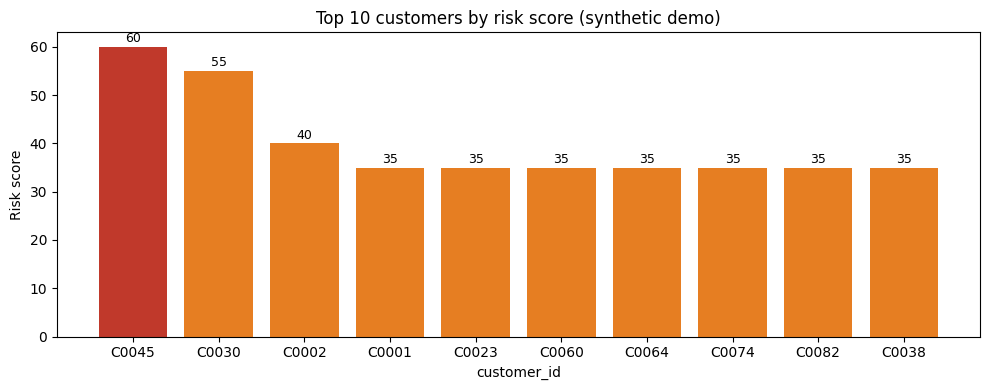

In [8]:
# 상위 10 고객 위험 점수 막대그래프
top10 = alerts.head(10)
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"High": "#c0392b", "Medium": "#e67e22", "Low": "#95a5a6"}
bar_colors = [colors[t] for t in top10["risk_tier"]]
ax.bar(top10["customer_id"], top10["risk_score"], color=bar_colors)
ax.set_title("Top 10 customers by risk score (synthetic demo)")
ax.set_ylabel("Risk score")
ax.set_xlabel("customer_id")
for i, v in enumerate(top10["risk_score"]):
    ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## Step 4. Generate alert reasons (human-readable)

담당자가 바로 스캔할 수 있도록 룰별 근거를 문장 단위로 조립합니다.


In [9]:
rule_to_sentence = {
    "daily_cash_aggregation":      "동일 영업일 현금 합계 10백만원 이상",
    "structured_transactions":     "7일 이내 9백만~9백99만원 거래 3회 이상 (CTR 회피 의심)",
    "new_account_large_txn":       "계좌 개설 30일 이내 5백만원 초과 거래",
    "shared_device_multi_account": "3개 이상 계정이 공유하는 단말기 사용",
    "profile_mismatch":            "저소득 신고 고객 월 거래액 50백만원 초과",
}

def reason(rules_csv: str) -> str:
    pieces = [rule_to_sentence[r] for r in rules_csv.split(", ")]
    return " / ".join(pieces)

alerts["alert_reason"] = alerts["triggered_rules"].apply(reason)
alerts.head(10)[["customer_id", "risk_tier", "risk_score", "alert_reason"]]


,customer_id,risk_tier,risk_score,alert_reason
0,C0045,High,60,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사...
1,C0030,Medium,55,계좌 개설 30일 이내 5백만원 초과 거래 / 저소득 신고 고객 월 거래액 50백만...
2,C0002,Medium,40,3개 이상 계정이 공유하는 단말기 사용 / 7일 이내 9백만~9백99만원 거래 3회...
3,C0001,Medium,35,동일 영업일 현금 합계 10백만원 이상 / 3개 이상 계정이 공유하는 단말기 사용
4,C0023,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용
5,C0060,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용
6,C0064,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용
7,C0074,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용
8,C0082,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용
9,C0038,Medium,35,계좌 개설 30일 이내 5백만원 초과 거래 / 3개 이상 계정이 공유하는 단말기 사용


In [10]:
# CSV로 저장
out_path = OUT_DIR / "sample_alerts.csv"
alerts.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Saved -> {out_path}")
print(f"Tier breakdown:")
print(alerts["risk_tier"].value_counts())


Saved -> ..\outputs\sample_alerts.csv
Tier breakdown:
risk_tier
Low       63
Medium    16
High       1
Name: count, dtype: int64


## Limitations

- This demo uses rule-based detection only. Production systems combine rule-based triggers with ML models for false positive reduction.
- Thresholds are illustrative. The 1천만원 threshold reflects the CTR reporting standard; other thresholds are examples that require calibration against real transaction volume distributions.
- Risk scores here are heuristic weights, not statistically validated.
- Final STR/CTR filing decision requires human analyst review with full customer context.
